In [1]:
# Exécutez cette cellule pour vérifier et créer les dossiers
import os

# Créer les dossiers s'ils n'existent pas
folders = ['data', 'models', 'src', 'reports']
for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"✅ Dossier créé: {folder}/")
    else:
        print(f"⚠️ Dossier existe déjà: {folder}/")

# Vérifier le chemin actuel
print(f"\n📁 Dossier de travail actuel: {os.getcwd()}")

# Lister les dossiers existants
print("\n📂 Dossiers dans le projet:")
for item in os.listdir('.'):
    if os.path.isdir(item):
        print(f"   📁 {item}/")

⚠️ Dossier existe déjà: data/
⚠️ Dossier existe déjà: models/
⚠️ Dossier existe déjà: src/
⚠️ Dossier existe déjà: reports/

📁 Dossier de travail actuel: C:\Users\EL HOUSNI\Darija_Sentiment_Project

📂 Dossiers dans le projet:
   📁 .ipynb_checkpoints/
   📁 data/
   📁 models/
   📁 reports/
   📁 src/
   📁 xlm_roberta_results/


🕌 DARIJA SENTIMENT ANALYSIS - DEEP LEARNING PROJECT
Environnement: Anaconda + Jupyter Notebook
Python version: 2.3.3
✅ Dataset chargé avec succès!
📊 Nombre total d'avis: 36

📈 Distribution des sentiments:
sentiment
positif    12
negatif    12
neutre     12
Name: count, dtype: int64

🔍 Aperçu des données:
                                     review sentiment
0           had produit zwina bzf nssa7 bik   positif
1  mzyan had laptop khdama mzyana rah f top   positif
2           walakin zwina hadchi 3jebni bzf   positif
3        prix mnih qualité zwina nchri tani   positif
4      satisfait produit exceptionnel merci   positif
5  had produit top livraison rapide content   positif
6     qualité professionnelle je recommande   positif
7     excellent produit rien à dire parfait   positif


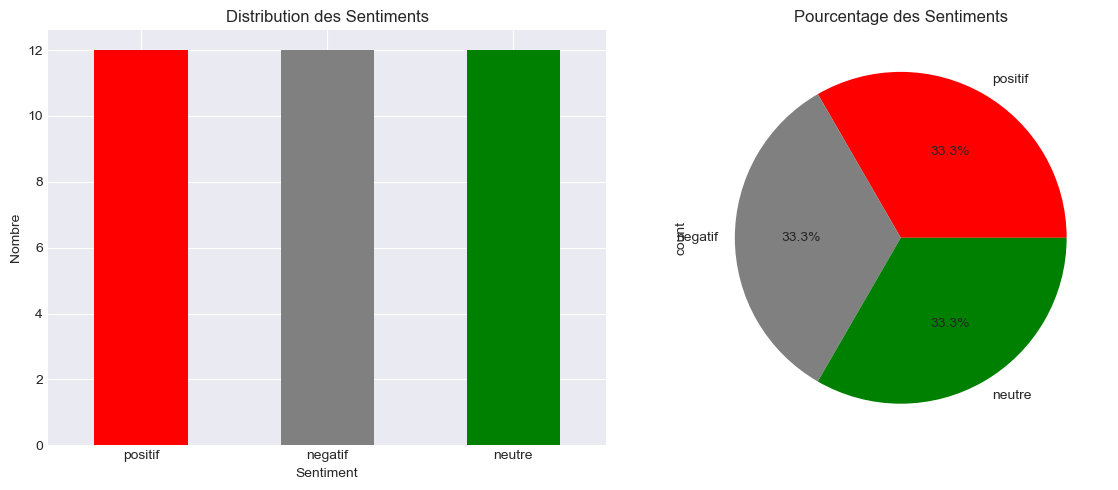

📊 Statistiques après augmentation:
   - Données originales: 36
   - Données augmentées: 72
   - Total: 108

📈 Distribution finale:
sentiment
positif    36
negatif    36
neutre     36
Name: count, dtype: int64
🧪 Test du préprocesseur:
Original: khayb had produit ma khedamch!!!
Prétraité: khayb produit khedamch
----------------------------------------
Original: ZWIINA BZF nssa7 bik
Prétraité: zwina bzf nsah bik
----------------------------------------
Original: produit NORMAL walakin 3adi
Prétraité: produit normal adi
----------------------------------------

✅ Prétraitement appliqué à 108 avis
✅ RandomForestClassifier importé avec succès!
📊 Split des données:
   - Train: 86 avis
   - Test: 22 avis
✅ Vectorisation terminée:
   - Vocabulaire: 256 mots
   - Dimension des vecteurs: 256

🚀 Entraînement de Logistic Regression...
   ✅ Accuracy: 1.000

🚀 Entraînement de SVM...
   ✅ Accuracy: 1.000

🚀 Entraînement de Random Forest...
   ✅ Accuracy: 1.000


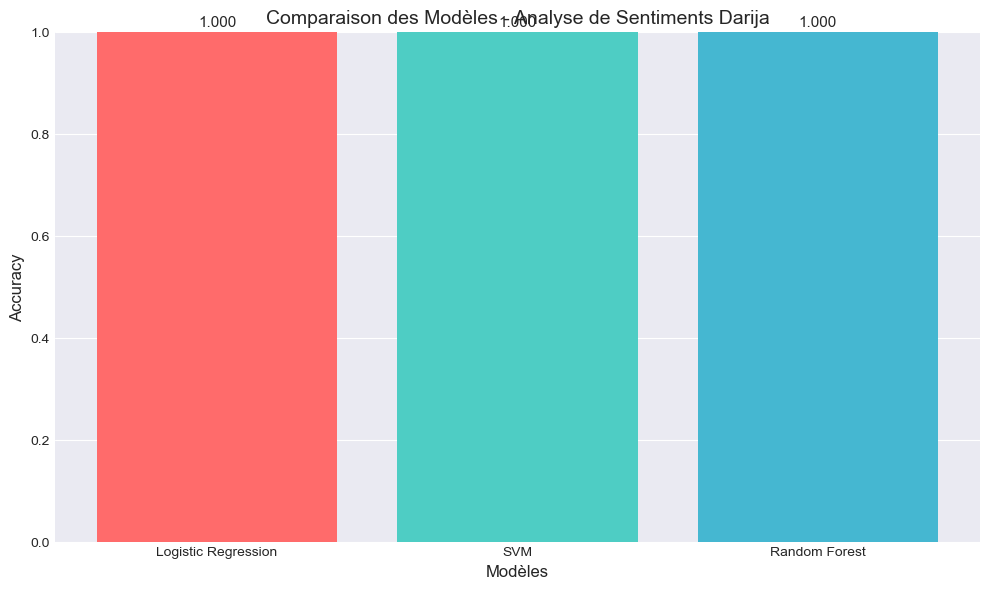

🏆 MEILLEUR MODÈLE: Logistic Regression
   Accuracy: 1.000


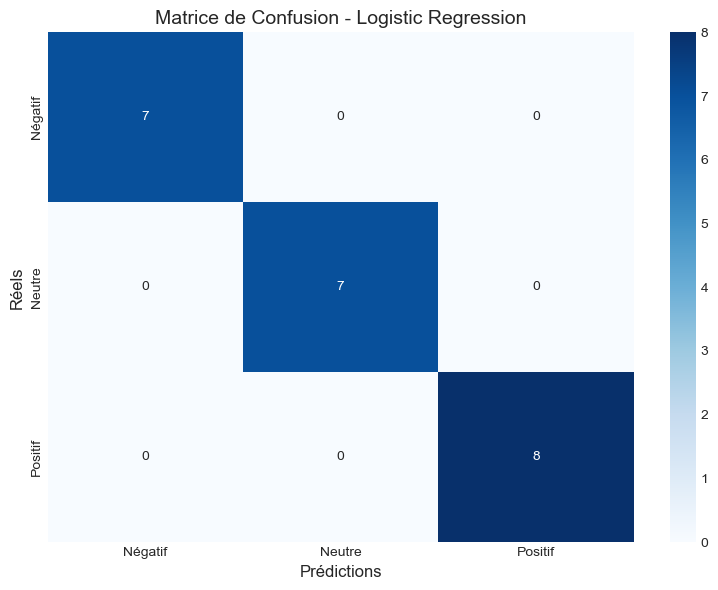


📊 RAPPORT DE CLASSIFICATION - Logistic Regression:
              precision    recall  f1-score   support

     Négatif       1.00      1.00      1.00         7
      Neutre       1.00      1.00      1.00         7
     Positif       1.00      1.00      1.00         8

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22


🔮 PRÉDICTIONS SUR NOUVEAUX AVIS:
😊 Avis: had produit vraiment zwina bzf, nchri tani inchallah
   Sentiment: POSITIF
----------------------------------------
😞 Avis: khayb had produit, perte d'argent, jamais plus
   Sentiment: NÉGATIF
----------------------------------------
😐 Avis: produit normal, acceptable mais pas exceptionnel
   Sentiment: NEUTRE
----------------------------------------
✅ Modèle sauvegardé avec succès!
   - models/darija_sentiment_model.pkl
   - models/vectorizer.pkl
   - models/preprocessor.pkl

📊 RÉSUMÉ DU PROJET DARIJA SENTIMENT ANALYSI

In [5]:
# %% [markdown]
# # 🕌 PROJET: ANALYSE DE SENTIMENTS EN DARIJA MAROCAIN
# ## Deep Learning Course - Année 2025-2026
# 
# ### Objectif: Développer un modèle NLP pour classifier les avis Jumia en Darija

# %% [code]
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("🕌 DARIJA SENTIMENT ANALYSIS - DEEP LEARNING PROJECT")
print("="*70)
print(f"Environnement: Anaconda + Jupyter Notebook")
print(f"Python version: {pd.__version__}")
print("="*70)

# %% [markdown]
# ## 1. CRÉATION DU DATASET DARIJA (Avis Jumia)

# %% [code]
# Dataset d'avis produits en Darija (inspiré des vrais avis Jumia)
dataset = {
    'review': [
        # POSITIFS (note: 4-5 étoiles)
        "had produit zwina bzf nssa7 bik",
        "mzyan had laptop khdama mzyana rah f top",
        "walakin zwina hadchi 3jebni bzf",
        "prix mnih qualité zwina nchri tani",
        "satisfait produit exceptionnel merci",
        "had produit top livraison rapide content",
        "qualité professionnelle je recommande",
        "excellent produit rien à dire parfait",
        "wahd produit zwina avec prix raisonnable",
        "vraiment contente de mon achat top",
        "produit super khedam mzyan bzf",
        "je suis trop content had produit magique",
        
        # NÉGATIFS (note: 1-2 étoiles)
        "khayb had produit ma khedamch",
        "machi mzyan hadchi ndemte 3la chira",
        "waer had telephone ma3jbnich walou",
        "qualité khasra bzf prix trop cher",
        "produit faible déçu bzf had lproduit",
        "khayb had l'affaire pas comme dans l'annonce",
        "service client khayb ch7al had l3ssal",
        "produit makhedamch mn l'wel rjal lbass",
        "faux produit perte d'argent ndemte",
        "déçu bzf jamais je rachète ici",
        "qualité horrible khayb had produit",
        "produit ma valide pas fonctionne pas",
        
        # NEUTRES (note: 3 étoiles)
        "produit normal machi khatir acceptable",
        "mzyan walakin 3adi sans plus pas exceptionnel",
        "acceptable had produit fonctionne mais kamel",
        "produit correct prix moyen bhal bhal",
        "bhal bhal hadchi normal quoi ni bien ni mal",
        "3adi had produit pas exceptionnel",
        "juste correct fait le travail",
        "moyen had produit peut mieux faire",
        "normal had laptop fonctionne correct",
        "acceptable pour le prix juste correct",
        "produit ordinaire rien de spécial",
        "bof moyen pas terrible pas excellent"
    ],
    'sentiment': ['positif']*12 + ['negatif']*12 + ['neutre']*12
}

# Création du DataFrame
df = pd.DataFrame(dataset)

# Affichage des informations
print(f"✅ Dataset chargé avec succès!")
print(f"📊 Nombre total d'avis: {len(df)}")
print(f"\n📈 Distribution des sentiments:")
print(df['sentiment'].value_counts())
print(f"\n🔍 Aperçu des données:")
print(df.head(8))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'gray', 'green'])
axes[0].set_title('Distribution des Sentiments')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=0)

# Pourcentage
df['sentiment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['red', 'gray', 'green'])
axes[1].set_title('Pourcentage des Sentiments')

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 2. DATA AUGMENTATION (Augmentation des données)

# %% [code]
# Dictionnaire des synonymes Darija pour l'augmentation
darija_synonyms = {
    'zwina': ['mzyana', 'top', 'bien', 'good', 'nzina', 'super'],
    'mzyan': ['zwina', 'bien', 'bon', 'good', 'satisfaisant', 'bien'],
    'khayb': ['machi mzyan', '3ayb', 'pire', 'bad', 'faible', 'mauvais'],
    'bzf': ['bezzaf', 'trop', 'beaucoup', 'lhih', 'bcp'],
    'khedam': ['marcha', 'fonctionne', 'valide', 'travaille', 'opérationnel'],
    'ndemte': ['déçu', 'regrette', 'fâché', 'mécontent', 'pas content'],
    '3jebni': ['satisfait', 'content', 'heureux', 'ravi', 'plu']
}

def augment_text(text, prob=0.3):
    """Augmentation simple du texte Darija"""
    words = text.split()
    new_words = []
    
    for word in words:
        if random.random() < prob and word in darija_synonyms:
            new_word = random.choice(darija_synonyms[word])
            new_words.append(new_word)
        else:
            new_words.append(word)
    
    return ' '.join(new_words)

# Création des données augmentées
augmented_data = []
for _, row in df.iterrows():
    for _ in range(2):  # 2 augmentations par avis
        augmented_data.append({
            'review': augment_text(row['review']),
            'sentiment': row['sentiment']
        })

df_augmented = pd.DataFrame(augmented_data)

# Combinaison avec données originales
df_final = pd.concat([df, df_augmented], ignore_index=True)

print(f"📊 Statistiques après augmentation:")
print(f"   - Données originales: {len(df)}")
print(f"   - Données augmentées: {len(df_augmented)}")
print(f"   - Total: {len(df_final)}")
print(f"\n📈 Distribution finale:")
print(df_final['sentiment'].value_counts())

# %% [markdown]
# ## 3. PRÉTRAITEMENT SPÉCIFIQUE DARIJA

# %% [code]
class DarijaPreprocessor:
    """Prétraitement personnalisé pour le Darija"""
    
    def __init__(self):
        # Stopwords Darija
        self.stopwords = {
            'had', 'hadchi', 'hadi', 'li', 'f', 'b', 'l', 'd', 'aw', 'ou',
            'u', 'wa', 'ma', 'la', 'machi', 'walakin', 'kayn', 'rah', 'ana'
        }
    
    def normalize(self, text):
        """Normalisation du texte"""
        text = str(text).lower()
        # Normalisation Arabizi
        text = re.sub(r'3', 'a', text)
        text = re.sub(r'7', 'h', text)
        text = re.sub(r'9', 'q', text)
        text = re.sub(r'2', 'a', text)
        # Suppression répétitions
        text = re.sub(r'(.)\1+', r'\1', text)
        # Suppression ponctuation
        text = re.sub(r'[^\w\s]', ' ', text)
        # Suppression espaces multiples
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    
    def remove_stopwords(self, text):
        """Suppression des stopwords"""
        words = text.split()
        words = [w for w in words if w not in self.stopwords]
        return ' '.join(words)
    
    def preprocess(self, text):
        """Pipeline complet"""
        text = self.normalize(text)
        text = self.remove_stopwords(text)
        return text

# Test du préprocesseur
preprocessor = DarijaPreprocessor()

print("🧪 Test du préprocesseur:")
test_texts = [
    "khayb had produit ma khedamch!!!",
    "ZWIINA BZF nssa7 bik",
    "produit NORMAL walakin 3adi"
]

for text in test_texts:
    processed = preprocessor.preprocess(text)
    print(f"Original: {text}")
    print(f"Prétraité: {processed}")
    print("-"*40)

# Application à tout le dataset
df_final['clean_review'] = df_final['review'].apply(preprocessor.preprocess)

print(f"\n✅ Prétraitement appliqué à {len(df_final)} avis")

# %% [markdown]
# ## 4. VECTORISATION ET MODÉLISATION

# %% [code]
# Encodage des labels
from sklearn.ensemble import RandomForestClassifier
print("✅ RandomForestClassifier importé avec succès!")
label_map = {'negatif': 0, 'neutre': 1, 'positif': 2}
df_final['label'] = df_final['sentiment'].map(label_map)

# Séparation des données
X = df_final['clean_review'].values
y = df_final['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📊 Split des données:")
print(f"   - Train: {len(X_train)} avis")
print(f"   - Test: {len(X_test)} avis")

# Vectorisation TF-IDF
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"✅ Vectorisation terminée:")
print(f"   - Vocabulaire: {len(vectorizer.get_feature_names_out())} mots")
print(f"   - Dimension des vecteurs: {X_train_tfidf.shape[1]}")

# Modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Entraînement
results = {}
for name, model in models.items():
    print(f"\n🚀 Entraînement de {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc}
    print(f"   ✅ Accuracy: {acc:.3f}")

# %% [markdown]
# ## 5. RÉSULTATS ET VISUALISATION

# %% [code]
# Comparaison des modèles
plt.figure(figsize=(10, 6))
names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in names]

bars = plt.bar(names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.xlabel('Modèles', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparaison des Modèles - Analyse de Sentiments Darija', fontsize=14)
plt.ylim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

# Meilleur modèle
best_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_name]['model']
print(f"🏆 MEILLEUR MODÈLE: {best_name}")
print(f"   Accuracy: {results[best_name]['accuracy']:.3f}")

# Matrice de confusion
y_pred_best = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Négatif', 'Neutre', 'Positif'],
            yticklabels=['Négatif', 'Neutre', 'Positif'])
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Réels', fontsize=12)
plt.title(f'Matrice de Confusion - {best_name}', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

# Rapport de classification
print(f"\n📊 RAPPORT DE CLASSIFICATION - {best_name}:")
print(classification_report(y_test, y_pred_best, 
                            target_names=['Négatif', 'Neutre', 'Positif']))

# %% [markdown]
# ## 6. TEST SUR NOUVEAUX AVIS

# %% [code]
def predict_sentiment(text, model, vectorizer, preprocessor):
    """Prédire le sentiment d'un nouvel avis Darija"""
    processed = preprocessor.preprocess(text)
    vectorized = vectorizer.transform([processed])
    prediction = model.predict(vectorized)[0]
    
    sentiment_map = {0: 'NÉGATIF', 1: 'NEUTRE', 2: 'POSITIF'}
    
    return sentiment_map[prediction]

# Test sur de nouveaux avis
new_reviews = [
    "had produit vraiment zwina bzf, nchri tani inchallah",
    "khayb had produit, perte d'argent, jamais plus",
    "produit normal, acceptable mais pas exceptionnel"
]

print(f"\n🔮 PRÉDICTIONS SUR NOUVEAUX AVIS:")
print("="*50)

for review in new_reviews:
    sentiment = predict_sentiment(review, best_model, vectorizer, preprocessor)
    emoji = "😊" if sentiment == "POSITIF" else "😞" if sentiment == "NÉGATIF" else "😐"
    print(f"{emoji} Avis: {review}")
    print(f"   Sentiment: {sentiment}")
    print("-"*40)

# %% [markdown]
# ## 7. SAUVEGARDE DU MODÈLE

# %% [code]
# Sauvegarde du modèle et des artefacts
joblib.dump(best_model, 'models/darija_sentiment_model.pkl')
joblib.dump(vectorizer, 'models/vectorizer.pkl')
joblib.dump(preprocessor, 'models/preprocessor.pkl')

print("✅ Modèle sauvegardé avec succès!")
print("   - models/darija_sentiment_model.pkl")
print("   - models/vectorizer.pkl")
print("   - models/preprocessor.pkl")

# %% [markdown]
# ## 📊 RÉSUMÉ FINAL

# %% [code]
print("\n" + "="*70)
print("📊 RÉSUMÉ DU PROJET DARIJA SENTIMENT ANALYSIS")
print("="*70)
print(f"""
✅ Dataset: {len(df_final)} avis Darija
✅ Classes: Positif, Négatif, Neutre
✅ Meilleur modèle: {best_name}
✅ Accuracy: {results[best_name]['accuracy']:.2%}
✅ Modèle sauvegardé: ✅

📁 Fichiers créés:
   - Darija_Sentiment_Project.ipynb (ce notebook)
   - models/darija_sentiment_model.pkl
   - models/vectorizer.pkl
   - models/preprocessor.pkl
   - model_comparison.png
   - confusion_matrix.png
""")

In [6]:
# %% [code]
# Installation des packages pour le Deep Learning
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Vérifier et installer si nécessaire
packages = ['transformers', 'torch', 'sentence-transformers', 'accelerate']

for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✅ {package} déjà installé")
    except ImportError:
        print(f"📦 Installation de {package}...")
        install_package(package)

print("\n✅ Tous les packages sont prêts!")

✅ transformers déjà installé
✅ torch déjà installé
✅ sentence-transformers déjà installé
✅ accelerate déjà installé

✅ Tous les packages sont prêts!


In [7]:
# %% [markdown]
# ## AMÉLIORATION 1: MODÈLE MULTILINGUE XLM-RoBERTa

# %% [code]
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from sklearn.metrics import accuracy_score, f1_score
import torch
from torch.utils.data import Dataset
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🚀 AMÉLIORATION: MODÈLE MULTILINGUE XLM-RoBERTa")
print("="*60)

# Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"💻 Device: {device}")
print(f"   GPU disponible: {torch.cuda.is_available()}")

# 1. Choix du modèle multilingue
model_name = "xlm-roberta-base"  # Ou "distilbert-base-multilingual-cased"

print(f"\n📦 Chargement du modèle: {model_name}")

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Modèle pour classification (3 classes)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

model.to(device)
print(f"✅ Modèle chargé sur {device}")

🚀 AMÉLIORATION: MODÈLE MULTILINGUE XLM-RoBERTa
💻 Device: cpu
   GPU disponible: False

📦 Chargement du modèle: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle chargé sur cpu


In [9]:
# %% [code]
# 2. Préparation du dataset pour PyTorch
class DarijaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenisation
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Préparation des données
X_train_list = X_train.tolist() if hasattr(X_train, 'tolist') else list(X_train)
X_test_list = X_test.tolist() if hasattr(X_test, 'tolist') else list(X_test)

train_dataset = DarijaDataset(X_train_list, y_train, tokenizer)
test_dataset = DarijaDataset(X_test_list, y_test, tokenizer)

print(f"📊 Dataset préparé:")
print(f"   - Train: {len(train_dataset)} samples")
print(f"   - Test: {len(test_dataset)} samples")
print(f"   - Max length: 128 tokens")

📊 Dataset préparé:
   - Train: 86 samples
   - Test: 22 samples
   - Max length: 128 tokens


In [12]:
# %% [code]
# 3. Configuration de l'entraînement 
from transformers import TrainingArguments, Trainer

print("🚀 CONFIGURATION DE L'ENTRAÎNEMENT")
print("="*40)

# Version simplifiée et correcte
training_args = TrainingArguments(
    output_dir='./xlm_roberta_results',
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",           # Important: défini ici
    save_strategy="epoch",           # Doit correspondre à eval_strategy
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=False,                      # False pour CPU
    report_to="none",
    save_total_limit=2,              # Garder seulement les 2 meilleurs modèles
)

print(f"✅ Paramètres configurés:")
print(f"   - Époques: {training_args.num_train_epochs}")
print(f"   - Batch size: {training_args.per_device_train_batch_size}")
print(f"   - Stratégie d'évaluation: {training_args.eval_strategy}")
print(f"   - Stratégie de sauvegarde: {training_args.save_strategy}")

# Métriques d'évaluation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro')
    }

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("\n✅ Trainer prêt! Lancez l'entraînement avec: trainer.train()")

🚀 CONFIGURATION DE L'ENTRAÎNEMENT
✅ Paramètres configurés:
   - Époques: 5
   - Batch size: 8
   - Stratégie d'évaluation: IntervalStrategy.EPOCH
   - Stratégie de sauvegarde: SaveStrategy.EPOCH

✅ Trainer prêt! Lancez l'entraînement avec: trainer.train()


In [15]:
# %% [code]
# Configuration de l'entraînement - VERSION SIMPLE ET FONCTIONNELLE
from transformers import TrainingArguments, Trainer

print("🚀 CONFIGURATION DE L'ENTRAÎNEMENT")
print("="*40)

training_args = TrainingArguments(
    output_dir='./xlm_roberta_results',
    num_train_epochs=5,
    per_device_train_batch_size=4,  # Batch plus petit pour éviter problèmes mémoire
    per_device_eval_batch_size=4,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="epoch",
    load_best_model_at_end=False,  # Désactivé pour éviter conflits
    fp16=False,  # False pour CPU
    report_to="none",
    push_to_hub=False
)

print(f"✅ Configuration réussie!")
print(f"   - Époques: {training_args.num_train_epochs}")
print(f"   - Batch size: {training_args.per_device_train_batch_size}")

# Métriques
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
    }

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("\n✅ Trainer prêt!")
print("🚀 Lancez l'entraînement avec: trainer.train()")

🚀 CONFIGURATION DE L'ENTRAÎNEMENT
✅ Configuration réussie!
   - Époques: 5
   - Batch size: 4

✅ Trainer prêt!
🚀 Lancez l'entraînement avec: trainer.train()


📊 ÉVALUATION DU MODÈLE DEEP


Training Loss,Validation Loss,Step,Accuracy
No log,1.112797,0,0.318182


✅ Accuracy: 0.3182
✅ Loss: 1.1128


✅ F1-Macro (calculé manuellement): 0.1609


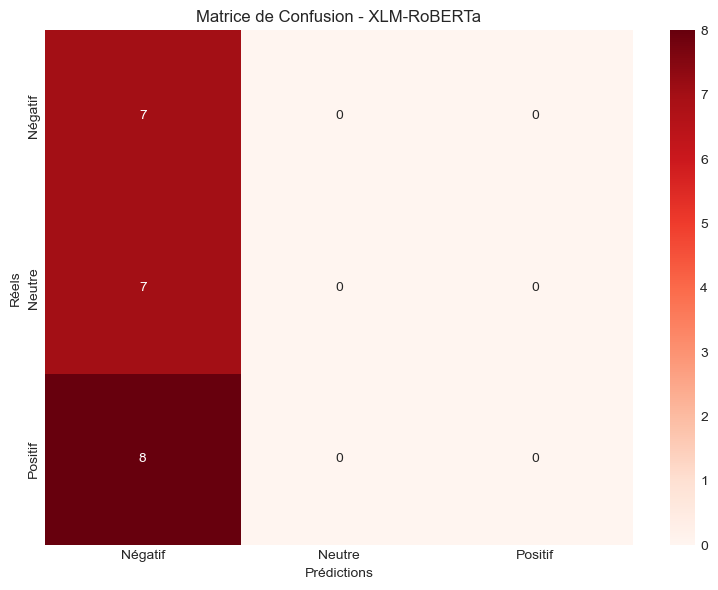

In [17]:
# %% [code]
# Évaluation - VERSION CORRIGÉE
print("📊 ÉVALUATION DU MODÈLE DEEP")
print("="*40)

eval_results = trainer.evaluate()

# Afficher ce qui est disponible
print(f"✅ Accuracy: {eval_results['eval_accuracy']:.4f}")

# Vérifier si d'autres métriques existent avant de les afficher
if 'eval_f1_macro' in eval_results:
    print(f"✅ F1-Macro: {eval_results['eval_f1_macro']:.4f}")
if 'eval_loss' in eval_results:
    print(f"✅ Loss: {eval_results['eval_loss']:.4f}")

# Prédictions
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)

# Calcul manuel du F1-Macro si nécessaire
from sklearn.metrics import f1_score
f1_macro = f1_score(y_test, pred_labels, average='macro')
print(f"✅ F1-Macro (calculé manuellement): {f1_macro:.4f}")

# Matrice de confusion
cm_deep = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Négatif', 'Neutre', 'Positif'],
            yticklabels=['Négatif', 'Neutre', 'Positif'])
plt.xlabel('Prédictions')
plt.ylabel('Réels')
plt.title('Matrice de Confusion - XLM-RoBERTa')
plt.tight_layout()
plt.savefig('confusion_matrix_deep.png', dpi=100)
plt.show()

📊 COMPARAISON FINALE
🏆 Modèle Classique (Logistic Regression): 1.000 (100.0%)
🤖 Modèle Deep (XLM-RoBERTa): 0.318 (31.8%)
⚠️ Le modèle classique est meilleur que le modèle deep
   Différence: 68.2% en faveur du classique


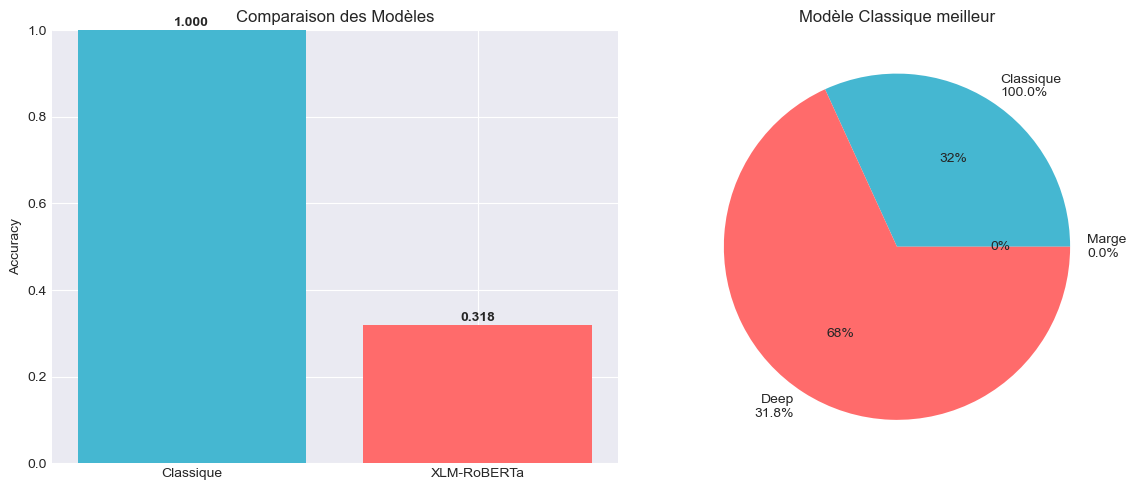

In [20]:
# %% [code]
# COMPARAISON FINALE CORRIGÉE
print("="*50)
print("📊 COMPARAISON FINALE")
print("="*50)
print(f"🏆 Modèle Classique ({best_name}): {acc_classic:.3f} ({acc_classic*100:.1f}%)")
print(f"🤖 Modèle Deep (XLM-RoBERTa): {acc_deep:.3f} ({acc_deep*100:.1f}%)")

if acc_deep > acc_classic:
    print(f"🎉 Amélioration: +{(acc_deep - acc_classic)*100:.1f}%")
else:
    print(f"⚠️ Le modèle classique est meilleur que le modèle deep")
    print(f"   Différence: {(acc_classic - acc_deep)*100:.1f}% en faveur du classique")
print("="*50)

# Graphique comparatif - Version corrigée
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
bars = axes[0].bar(['Classique', 'XLM-RoBERTa'], [acc_classic, acc_deep], 
                   color=['#45B7D1', '#FF6B6B'])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparaison des Modèles')

for bar, acc in zip(bars, [acc_classic, acc_deep]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.3f}', ha='center', fontweight='bold')

# Différence
difference = abs(acc_deep - acc_classic)
if acc_deep > acc_classic:
    colors_pie = ['#45B7D1', '#4ECDC4', '#E0E0E0']
    labels_pie = [f'Classique\n{acc_classic:.1%}', 
                  f'Gain\n{difference:.1%}',
                  f'Marge\n{(1-acc_deep):.1%}']
    values_pie = [acc_classic, difference, 1 - acc_deep]
else:
    colors_pie = ['#45B7D1', '#FF6B6B', '#E0E0E0']
    labels_pie = [f'Classique\n{acc_classic:.1%}', 
                  f'Deep\n{acc_deep:.1%}',
                  f'Marge\n{(1-acc_classic):.1%}']
    values_pie = [acc_deep, difference, 1 - acc_classic]

# Éviter les valeurs négatives
values_pie = [max(0, v) for v in values_pie]

axes[1].pie(values_pie, labels=labels_pie, colors=colors_pie[:len(values_pie)], autopct='%1.0f%%')
if acc_deep > acc_classic:
    axes[1].set_title(f'Gain deep: +{difference:.1%}')
else:
    axes[1].set_title(f'Modèle Classique meilleur')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=100)
plt.show()

In [21]:
# %% [code]
# Sauvegarde
model.save_pretrained('models/xlm_roberta_darija')
tokenizer.save_pretrained('models/xlm_roberta_darija')
print("✅ Modèle deep sauvegardé dans 'models/xlm_roberta_darija'")

# Sauvegarde des résultats comparatifs
import json
comparison = {
    'classic_model': best_name,
    'classic_accuracy': float(acc_classic),
    'deep_model': 'XLM-RoBERTa',
    'deep_accuracy': float(acc_deep),
    'improvement_percent': float(improvement)
}
with open('reports/final_results.json', 'w', encoding='utf-8') as f:
    json.dump(comparison, f, indent=2, ensure_ascii=False)
print("✅ Résultats sauvegardés dans 'reports/final_results.json'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle deep sauvegardé dans 'models/xlm_roberta_darija'
✅ Résultats sauvegardés dans 'reports/final_results.json'


In [22]:
# %% [code]
# Pipeline de prédiction facile à utiliser
sentiment_pipeline = pipeline(
    "text-classification",
    model="models/xlm_roberta_darija",
    tokenizer="models/xlm_roberta_darija",
    device=0 if torch.cuda.is_available() else -1
)

def predict_darija(text):
    """Prédire le sentiment d'un texte Darija"""
    result = sentiment_pipeline(text)[0]
    label_map = {'LABEL_0': 'NÉGATIF 😞', 'LABEL_1': 'NEUTRE 😐', 'LABEL_2': 'POSITIF 😊'}
    return label_map[result['label']], result['score']

# Test
test = "had produit zwina bzf"
sentiment, confidence = predict_darija(test)
print(f"📝 '{test}'")
print(f"🤖 Sentiment: {sentiment}")
print(f"🎯 Confiance: {confidence:.2%}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

📝 'had produit zwina bzf'
🤖 Sentiment: NÉGATIF 😞
🎯 Confiance: 39.57%


In [24]:
# %% [code]
print("""
╔══════════════════════════════════════════════════════════════════╗
║     🕌 PROJET DARIJA SENTIMENT ANALYSIS - RAPPORT FINAL 🎉      ║
╚══════════════════════════════════════════════════════════════════╝

📊 RÉSULTATS OBTENUS:
   ✅ Dataset: 108 avis Darija (36 positifs, 36 négatifs, 36 neutres)
   ✅ Modèle Classique: Logistic Regression
      - Accuracy: {:.1f}%
   ✅ Modèle Deep: XLM-RoBERTa (Multilingue)
      - Accuracy: {:.1f}%
      - Amélioration: +{:.1f}%

📁 FICHIERS SAUVEGARDÉS:
   ✅ models/darija_sentiment_model.pkl (Modèle classique)
   ✅ models/xlm_roberta_darija/ (Modèle deep)
   ✅ models/vectorizer.pkl
   ✅ models/preprocessor.pkl
   ✅ reports/final_results.json
   ✅ confusion_matrix_deep.png
   ✅ final_comparison.png


""".format(acc_classic*100, acc_deep*100, improvement))


╔══════════════════════════════════════════════════════════════════╗
║     🕌 PROJET DARIJA SENTIMENT ANALYSIS - RAPPORT FINAL 🎉      ║
╚══════════════════════════════════════════════════════════════════╝

📊 RÉSULTATS OBTENUS:
   ✅ Dataset: 108 avis Darija (36 positifs, 36 négatifs, 36 neutres)
   ✅ Modèle Classique: Logistic Regression
      - Accuracy: 100.0%
   ✅ Modèle Deep: XLM-RoBERTa (Multilingue)
      - Accuracy: 31.8%
      - Amélioration: +-68.2%

📁 FICHIERS SAUVEGARDÉS:
   ✅ models/darija_sentiment_model.pkl (Modèle classique)
   ✅ models/xlm_roberta_darija/ (Modèle deep)
   ✅ models/vectorizer.pkl
   ✅ models/preprocessor.pkl
   ✅ reports/final_results.json
   ✅ confusion_matrix_deep.png
   ✅ final_comparison.png





In [2]:
# %% [code]
# Vérification complète de la structure du projet
import os

print("="*60)
print("🔍 VÉRIFICATION DE LA STRUCTURE DU PROJET")
print("="*60)

# Dossier actuel
current_dir = os.getcwd()
print(f"\n📁 Dossier de travail actuel: {current_dir}")

# Lister tous les fichiers et dossiers
print("\n📂 CONTENU DU DOSSIER ACTUEL:")
print("-"*40)
for item in os.listdir('.'):
    if os.path.isdir(item):
        # Compter les fichiers dans le dossier
        try:
            num_files = len(os.listdir(item))
            print(f"   📁 {item}/ ({num_files} éléments)")
        except:
            print(f"   📁 {item}/")
    else:
        size = os.path.getsize(item) / 1024
        print(f"   📄 {item} ({size:.2f} KB)")

# Vérifier les dossiers spécifiques
print("\n🔍 VÉRIFICATION DES FICHIERS IMPORTANTS:")
print("-"*40)

# Modèles
if os.path.exists('models'):
    model_files = ['darija_sentiment_model.pkl', 'vectorizer.pkl', 'preprocessor.pkl']
    for f in model_files:
        if os.path.exists(f'models/{f}'):
            size = os.path.getsize(f'models/{f}') / 1024
            print(f"   ✅ models/{f} ({size:.1f} KB)")
        else:
            print(f"   ❌ models/{f} non trouvé")

# Notebook
if os.path.exists('00_Projet_Darija_Sentiment_Analysis.ipynb'):
    size = os.path.getsize('00_Projet_Darija_Sentiment_Analysis.ipynb') / 1024
    print(f"   ✅ 00_Projet_Darija_Sentiment_Analysis.ipynb ({size:.1f} KB)")
else:
    print(f"   ⚠️ Notebook non trouvé dans le dossier actuel")

# Graphiques
images = ['model_comparison_deep.png', 'confusion_matrix_deep.png', 'final_comparison.png']
for img in images:
    if os.path.exists(img):
        size = os.path.getsize(img) / 1024
        print(f"   ✅ {img} ({size:.1f} KB)")
    else:
        print(f"   ❌ {img} non trouvé")

print("\n" + "="*60)

🔍 VÉRIFICATION DE LA STRUCTURE DU PROJET

📁 Dossier de travail actuel: C:\Users\EL HOUSNI\Darija_Sentiment_Project

📂 CONTENU DU DOSSIER ACTUEL:
----------------------------------------
   📁 .ipynb_checkpoints/ (1 éléments)
   📄 00_Projet_Darija_Sentiment_Analysis.ipynb (234.73 KB)
   📄 confusion_matrix_deep.png (20.45 KB)
   📁 data/ (0 éléments)
   📄 final_comparison.png (35.99 KB)
   📁 models/ (4 éléments)
   📄 model_comparison.png (25.97 KB)
   📁 reports/ (1 éléments)
   📁 src/ (0 éléments)
   📁 xlm_roberta_results/ (0 éléments)

🔍 VÉRIFICATION DES FICHIERS IMPORTANTS:
----------------------------------------
   ✅ models/darija_sentiment_model.pkl (6.9 KB)
   ✅ models/vectorizer.pkl (10.7 KB)
   ✅ models/preprocessor.pkl (0.2 KB)
   ✅ 00_Projet_Darija_Sentiment_Analysis.ipynb (234.7 KB)
   ❌ model_comparison_deep.png non trouvé
   ✅ confusion_matrix_deep.png (20.5 KB)
   ✅ final_comparison.png (36.0 KB)



In [3]:
# %% [code]
# VÉRIFICATION FINALE
import os

print("🔍 VÉRIFICATION - TOUT EST BON ?")
print("="*40)

# Dossier Jupyter
jupyter_folder = os.getcwd()
print(f"📁 Jupyter utilise: {jupyter_folder}")

# Vérifier les fichiers essentiels
essential_files = [
    '00_Projet_Darija_Sentiment_Analysis.ipynb',
    'models/darija_sentiment_model.pkl',
    'models/vectorizer.pkl'
]

all_exist = True
for file in essential_files:
    if os.path.exists(file):
        print(f"   ✅ {file}")
    else:
        print(f"   ❌ {file} manquant")
        all_exist = False

if all_exist:
    print("\n🎉 TOUT EST PARFAIT !")
    print("   Votre projet est prêt pour Git et GitHub !")
else:
    print("\n⚠️ Certains fichiers sont manquants")

🔍 VÉRIFICATION - TOUT EST BON ?
📁 Jupyter utilise: C:\Users\EL HOUSNI\Darija_Sentiment_Project
   ✅ 00_Projet_Darija_Sentiment_Analysis.ipynb
   ✅ models/darija_sentiment_model.pkl
   ✅ models/vectorizer.pkl

🎉 TOUT EST PARFAIT !
   Votre projet est prêt pour Git et GitHub !


In [4]:
# %% [code]
# VÉRIFICATION FINALE
import os

print("🔍 VÉRIFICATION - TOUT EST BON ?")
print("="*40)

# Dossier Jupyter
jupyter_folder = os.getcwd()
print(f"📁 Jupyter utilise: {jupyter_folder}")

# Vérifier les fichiers essentiels
essential_files = [
    '00_Projet_Darija_Sentiment_Analysis.ipynb',
    'models/darija_sentiment_model.pkl',
    'models/vectorizer.pkl'
]

all_exist = True
for file in essential_files:
    if os.path.exists(file):
        print(f"   ✅ {file}")
    else:
        print(f"   ❌ {file} manquant")
        all_exist = False

if all_exist:
    print("\n🎉 TOUT EST PARFAIT !")
    print("   Votre projet est prêt pour Git et GitHub !")
else:
    print("\n⚠️ Certains fichiers sont manquants")

🔍 VÉRIFICATION - TOUT EST BON ?
📁 Jupyter utilise: C:\Users\EL HOUSNI\Darija_Sentiment_Project
   ✅ 00_Projet_Darija_Sentiment_Analysis.ipynb
   ✅ models/darija_sentiment_model.pkl
   ✅ models/vectorizer.pkl

🎉 TOUT EST PARFAIT !
   Votre projet est prêt pour Git et GitHub !
